# Models evaluation - Test 4 (Bracket Closing)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()
device = "cuda"

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

brackets = "({["

brackets_ix = []

for bracket in brackets:
    brackets_ix.append(vocab[bracket])

bracket_values = torch.tensor(brackets_ix, device=device)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

print("Ix of {: ", vocab["{"], " ix of }: ", vocab["}"])
print("Ix of [: ", vocab["["], " ix of ]: ", vocab["]"])
print("Ix of (: ", vocab["("], " ix of ): ", vocab[")"])

Ix of {:  36  ix of }:  37
Ix of [:  40  ix of ]:  41
Ix of (:  38  ix of ):  39


In [2]:
def get_batch_ex4(batch_size, bracket_values, vocab, buffer_size=50, device="cuda"):
    #Note - buffer size and copy size are IDENTICAL in this task.
    # buffer_size = 500 means that the model has to READ and WRITE 500 tokens.

    brackets_tensor = bracket_values[torch.randint(len(bracket_values), size=(batch_size, buffer_size), device=device)]
    copy_tensor = torch.flip(brackets_tensor, dims=[1])
    copy_tensor = copy_tensor + 1 # We exploit a cool vocab trick - the closed brackets are just the next index.
    

    marker_tensor = torch.full(
        (batch_size, 1),
        vocab["<STARTTASK>"],
        device=device,
    )

    ready_tensor = torch.cat([brackets_tensor, marker_tensor], dim=-1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor

def evaluate_ex4(model, bracket_values, buffer_size, total_batches, batch_size, vocab):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0
    with torch.no_grad():
        model.eval()
        for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

            batch, targets = get_batch_ex4(batch_size, bracket_values, vocab, buffer_size) #targets = (batch, seq)
            model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

            logits = model.forward(batch, model_targets) # (batch, seq, emb)
            tokens = torch.argmax(logits, dim=2) # (batch, seq)

            difference = targets - tokens #we'll get some number where the numbers are not the same

            difference = (difference !=0).float()

            num_elements = buffer_size * batch_size

            num_different = torch.sum(difference)

            avg_difference = num_different / num_elements

            avg_difference_sum = avg_difference_sum + avg_difference.item()

        model.train()

    return avg_difference_sum / (total_batches+1)



In [3]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Bracket closing task')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex4(model, batch_size, total_batches, test_batches, bracket_values, buffer_size, opt, test_break, model_name,
                     steps_history, train_history, test_history, vocab):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(25, buffer_size)

        batch, targets = get_batch_ex4(batch_size, bracket_values, vocab, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex4")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex4(batch_size, bracket_values, vocab, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [4]:
import custom_models

hid=256
m_hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

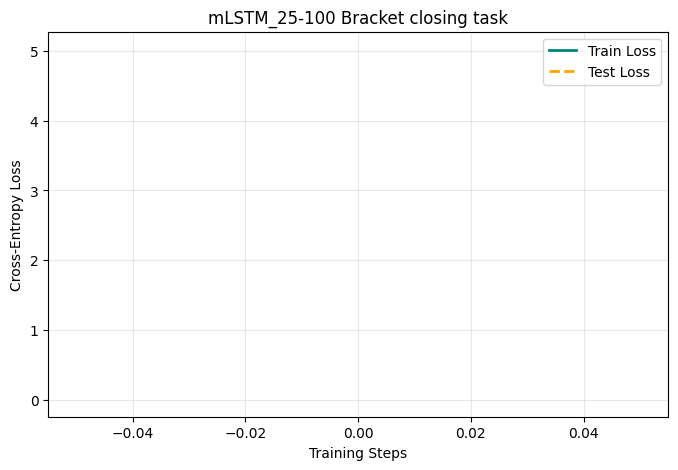

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 5.0234


  0%|          | 0/10 [00:00<?, ?it/s]

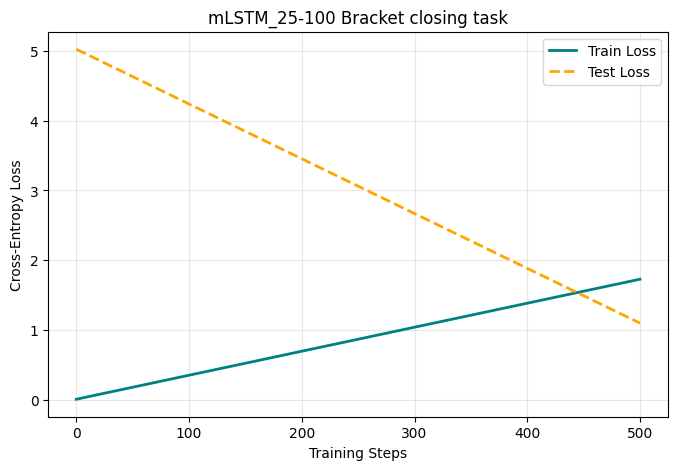

STEP: 500 | TRAIN LOSS: 1.7290 | TEST LOSS: 1.1002


  0%|          | 0/10 [00:00<?, ?it/s]

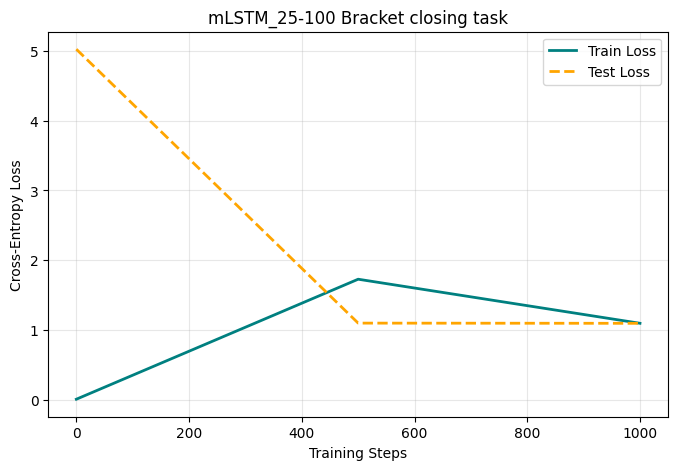

STEP: 1000 | TRAIN LOSS: 1.0978 | TEST LOSS: 1.0973


In [ ]:
run_training_ex4(model=mLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_mLSTM, 
                 test_break=500, 
                 model_name="mLSTM_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=mLSTMLite_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_mLSTMLite, 
                 test_break=500, 
                 model_name="mLSTMLite_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=sLSTM_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=MGU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_MGU, 
                 test_break=500, 
                 model_name="MGU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=GRU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_GRU, 
                 test_break=500, 
                 model_name="GRU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=maGRU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

In [ ]:
steps_history = []
train_history = []
test_history = []

run_training_ex4(model=eGRU_model, 
                 batch_size=batch_size, 
                 total_batches=total_batches, 
                 test_batches=test_batches, 
                 bracket_values=bracket_values, 
                 buffer_size=buffer_size, 
                 opt=opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_25-100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

## Testing the models!

In [9]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [ ]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

load_model("mLSTM_25-100_ex4_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("mLSTMLite_25-100_ex4_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("sLSTM_25-100_ex4_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("MGU_25-100_ex4_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("maGRU_25-100_ex4_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("GRU_25-100_ex4_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("eGRU_25-100_ex4_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)


7001

In [ ]:

ex1_mlstm_50   =  evaluate_ex4(mLSTM_model, bracket_values, buffer_size=15,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_100  =  evaluate_ex4(mLSTM_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_250  =  evaluate_ex4(mLSTM_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_500  =  evaluate_ex4(mLSTM_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_750  =  evaluate_ex4(mLSTM_model, bracket_values, buffer_size=100,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_1000 = evaluate_ex4(mLSTM_model, bracket_values,  buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTM bracket closing difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM bracket closing difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM bracket closing difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM bracket closing difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM bracket closing difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM bracket closing difference at buffer_size=1000: ", ex1_mlstm_1000)

In [ ]:

ex1_mlstmlite_50   = evaluate_ex4(mLSTMLite_model, bracket_values, buffer_size=15,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_100  = evaluate_ex4(mLSTMLite_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_250  = evaluate_ex4(mLSTMLite_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_500  = evaluate_ex4(mLSTMLite_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_750  = evaluate_ex4(mLSTMLite_model, bracket_values, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_1000 = evaluate_ex4(mLSTMLite_model, bracket_values, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTMLite bracket closing difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite bracket closing difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite bracket closing difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite bracket closing difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite bracket closing difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite bracket closing difference at buffer_size=1000: ", ex1_mlstmlite_1000)

In [ ]:

ex1_cgru_50 =   evaluate_ex4(GRU_model, bracket_values, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_100 =  evaluate_ex4(GRU_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_250 =  evaluate_ex4(GRU_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_500 =  evaluate_ex4(GRU_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_750 =  evaluate_ex4(GRU_model, bracket_values, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_1000 = evaluate_ex4(GRU_model, bracket_values, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("GRU bracket closing difference at buffer_size=50: ", ex1_cgru_50)
print("GRU bracket closing difference at buffer_size=100: ", ex1_cgru_100)
print("GRU bracket closing difference at buffer_size=250: ", ex1_cgru_250)
print("GRU bracket closing difference at buffer_size=500: ", ex1_cgru_500)
print("GRU bracket closing difference at buffer_size=750: ", ex1_cgru_750)
print("GRU bracket closing difference at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU bracket closing difference at buffer_size=50:  0.1941150949142947
GRU bracket closing difference at buffer_size=100:  0.3437407096423725
GRU bracket closing difference at buffer_size=250:  0.577731463578668
GRU bracket closing difference at buffer_size=500:  0.6325303510864182
GRU bracket closing difference at buffer_size=750:  0.6465317618728864
GRU bracket closing difference at buffer_size=1000:  0.652643903647319


In [ ]:
ex1_mgu_50 =   evaluate_ex4(MGU_model, bracket_values, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_100 =  evaluate_ex4(MGU_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_250 =  evaluate_ex4(MGU_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_500 =  evaluate_ex4(MGU_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_750 =  evaluate_ex4(MGU_model, bracket_values, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_1000 = evaluate_ex4(MGU_model, bracket_values, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("MGU bracket closing difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU bracket closing difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU bracket closing difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU bracket closing difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU bracket closing difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU bracket closing difference at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU bracket closing difference at buffer_size=50:  0.5028093929337983
MGU bracket closing difference at buffer_size=100:  0.5579733795458728
MGU bracket closing difference at buffer_size=250:  0.6123713166406839
MGU bracket closing difference at buffer_size=500:  0.6506491651629457
MGU bracket closing difference at buffer_size=750:  0.6579261487073237
MGU bracket closing difference at buffer_size=1000:  0.6608239801803438


In [ ]:
ex1_slstm_50 =   evaluate_ex4(sLSTM_model, bracket_values, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_100 =  evaluate_ex4(sLSTM_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_250 =  evaluate_ex4(sLSTM_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_500 =  evaluate_ex4(sLSTM_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_750 =  evaluate_ex4(sLSTM_model, bracket_values, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_1000 = evaluate_ex4(sLSTM_model, bracket_values, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("sLSTM bracket closing difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM bracket closing difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM bracket closing difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM bracket closing difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM bracket closing difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM bracket closing difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM bracket closing difference at buffer_size=50:  0.3367945475153404
sLSTM bracket closing difference at buffer_size=100:  0.43971224350504357
sLSTM bracket closing difference at buffer_size=250:  0.5916510171229297
sLSTM bracket closing difference at buffer_size=500:  0.6347568395114181
sLSTM bracket closing difference at buffer_size=750:  0.6455490825199844
sLSTM bracket closing difference at buffer_size=1000:  0.6514585755839206


In [ ]:
ex1_magru_50 =   evaluate_ex4(maGRU_model, bracket_values, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_100 =  evaluate_ex4(maGRU_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_250 =  evaluate_ex4(maGRU_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_500 =  evaluate_ex4(maGRU_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_750 =  evaluate_ex4(maGRU_model, bracket_values, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_1000 = evaluate_ex4(maGRU_model, bracket_values, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("maGRU bracket closing difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU bracket closing difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU bracket closing difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU bracket closing difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU bracket closing difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU bracket closing difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU bracket closing difference at buffer_size=50:  0.2806559346690036
maGRU bracket closing difference at buffer_size=100:  0.3987561782987991
maGRU bracket closing difference at buffer_size=250:  0.5863576997624765
maGRU bracket closing difference at buffer_size=500:  0.6509950774731023
maGRU bracket closing difference at buffer_size=750:  0.6587343168730783
maGRU bracket closing difference at buffer_size=1000:  0.6612685954216684


In [ ]:
ex1_eGRU_50 =   evaluate_ex4(eGRU_model, bracket_values, buffer_size=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_100 =  evaluate_ex4(eGRU_model, bracket_values, buffer_size=25,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_250 =  evaluate_ex4(eGRU_model, bracket_values, buffer_size=50,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_500 =  evaluate_ex4(eGRU_model, bracket_values, buffer_size=75,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_750 =  evaluate_ex4(eGRU_model, bracket_values, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex4(eGRU_model, bracket_values, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("eGRU bracket closing difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU bracket closing difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU bracket closing difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU bracket closing difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU bracket closing difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU bracket closing difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU bracket closing difference at buffer_size=50:  0.3344059335713339
eGRU bracket closing difference at buffer_size=100:  0.44510518884894873
eGRU bracket closing difference at buffer_size=250:  0.5821807201546018
eGRU bracket closing difference at buffer_size=500:  0.6257797332093267
eGRU bracket closing difference at buffer_size=750:  0.6391571724768912
eGRU bracket closing difference at buffer_size=1000:  0.6461971231026225


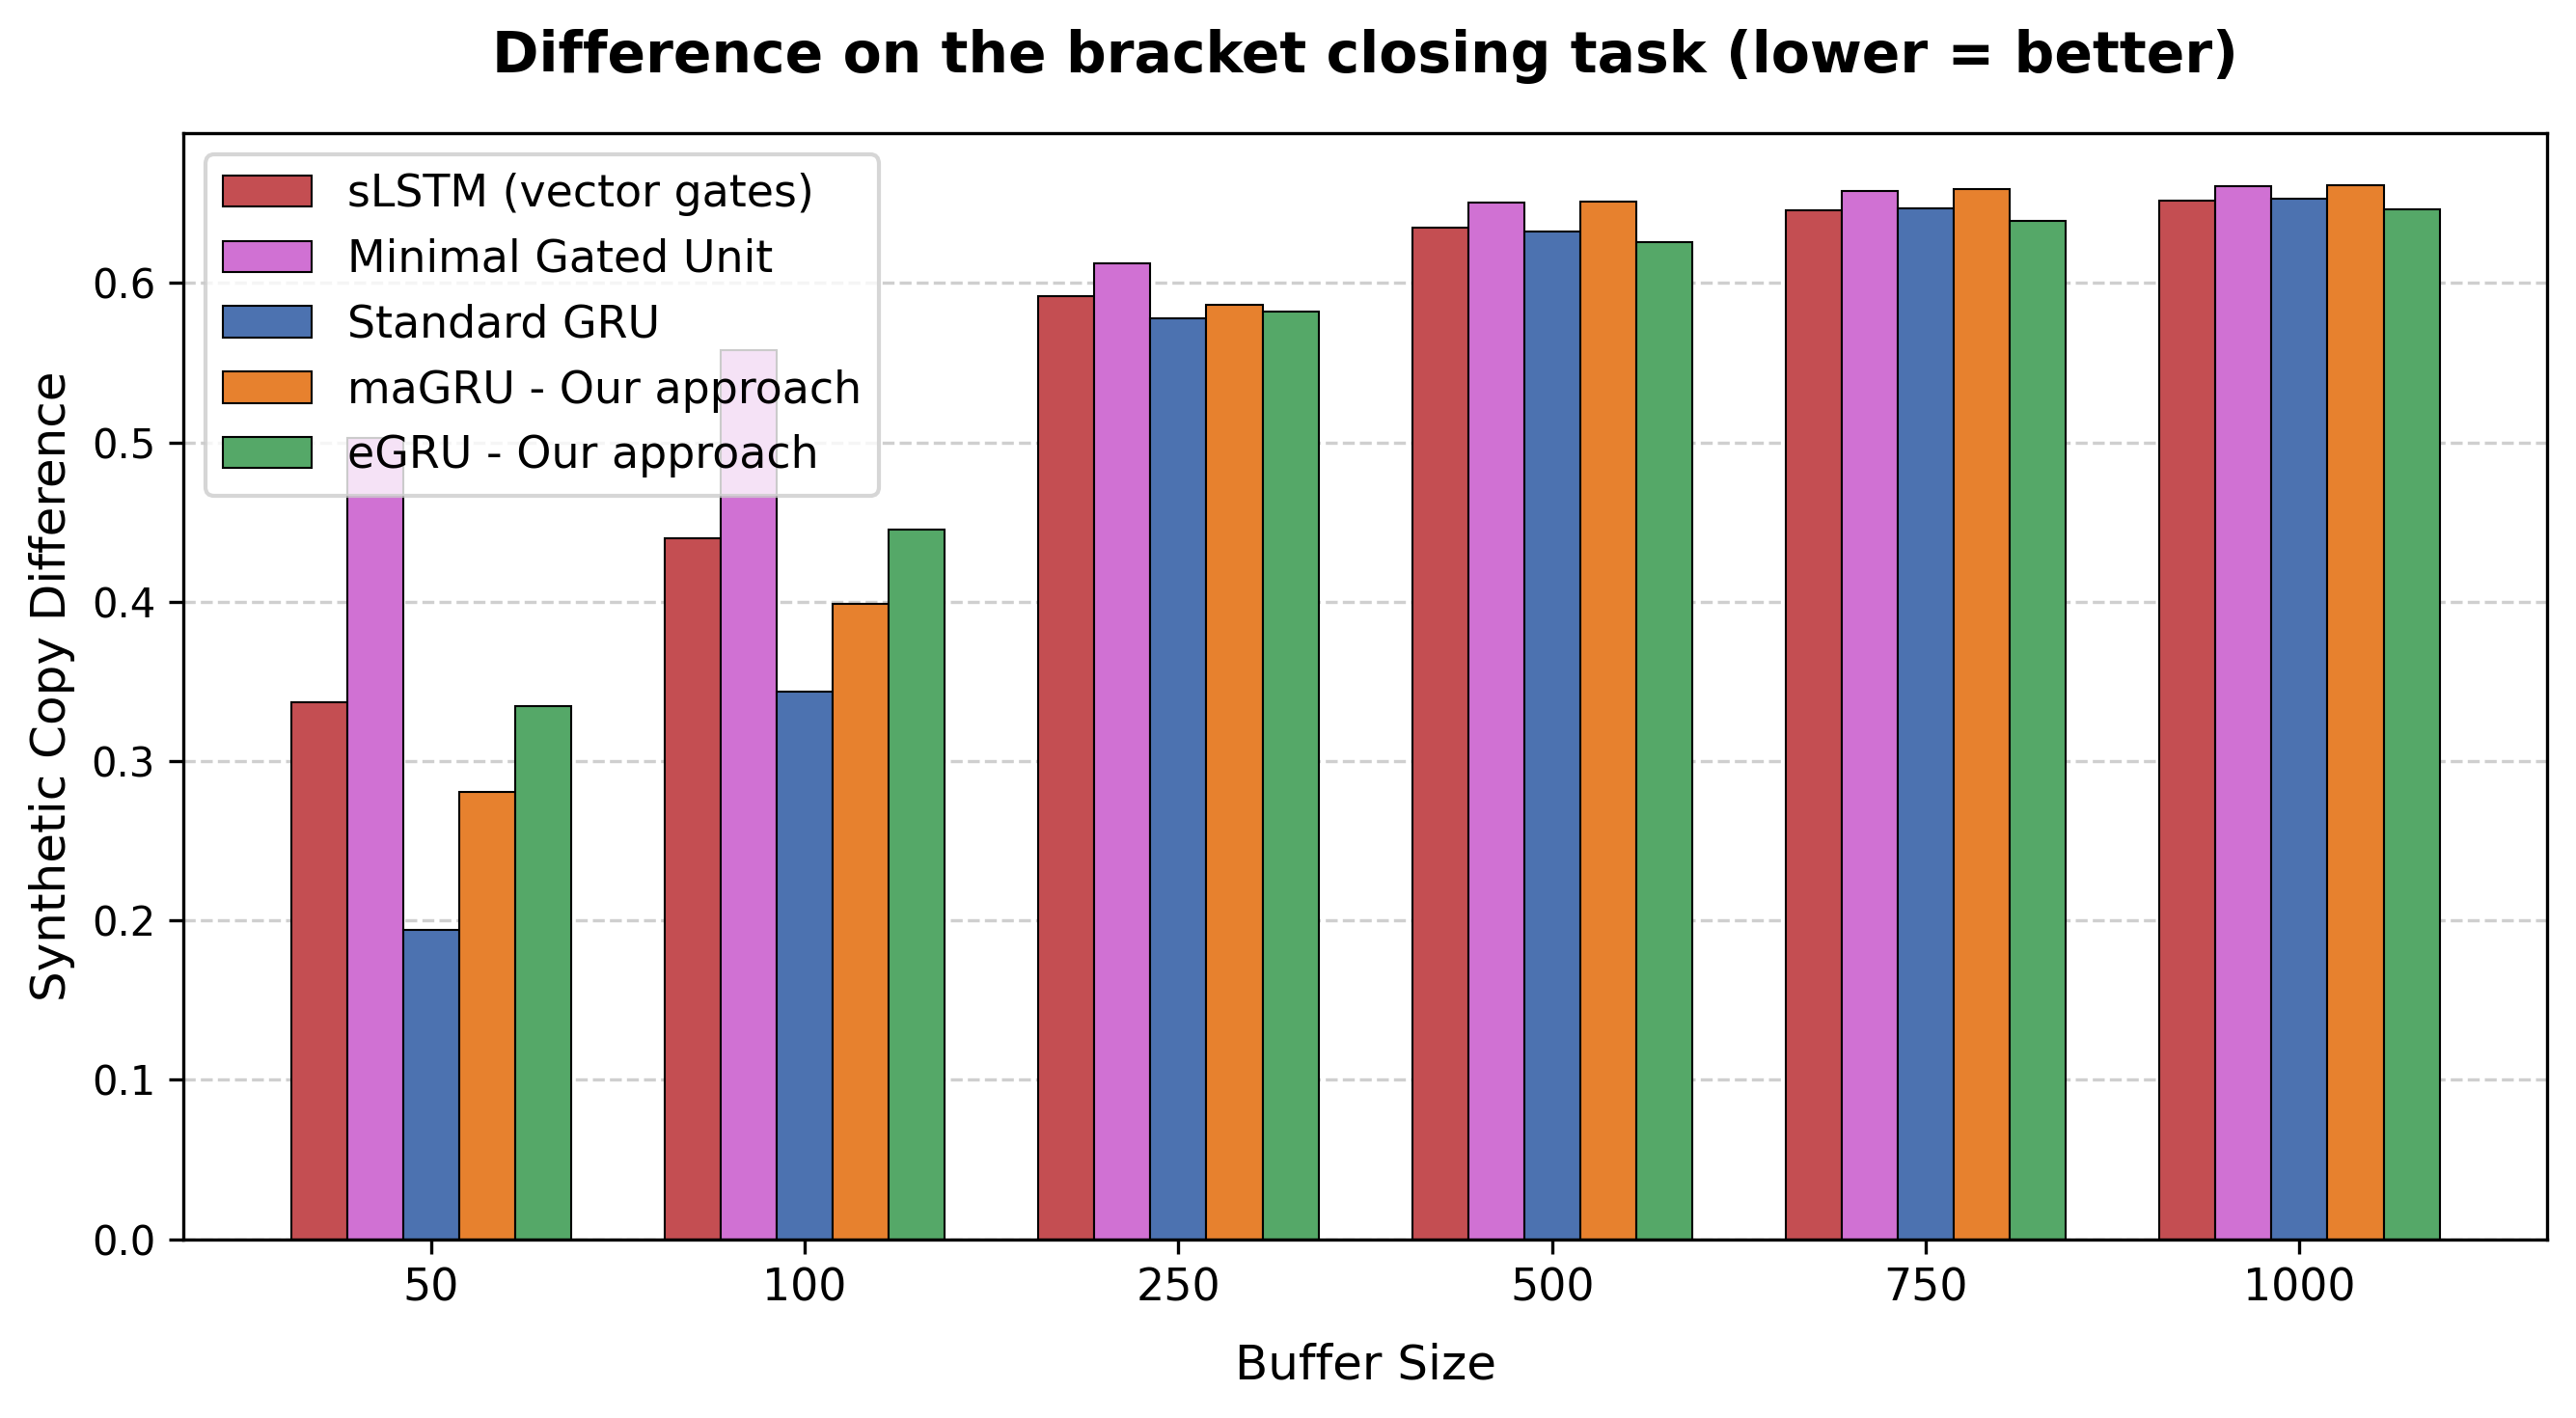

In [ ]:
standard_gru = [
    0.6423267326732673,
     0.7233910891089109,
     0.7676361386138614,
     0.7803217821782178,
     0.8146658415841584,
      0.823019801980198
]

egru = [
    0.6454207920792079,
     0.7465965346534653,
     0.7973391089108911,
     0.8078589108910891,
     0.8536509900990099,
      0.869740099009901
]

magru = [
    0.7719678217821783,
     0.8391089108910891,
     0.8725247524752475,
     0.8821163366336634,
     0.8938737623762376,
      0.8975866336633663
]

MGU = [
    0.7614480198019802,
     0.8403465346534653,
     0.8604579207920792,
     0.8762376237623762,
     0.8845915841584159,
      0.901299504950495
]

sLSTM = [
    0.6488242574257426,
     0.7382425742574258,
     0.7710396039603961,
     0.807549504950495,
     0.8251856435643564,
      0.8681930693069307
]

mLSTM = [
    0.6413985148514851,
    0.7199876237623762,
    0.7719678217821783,
    0.7766089108910891,
    0.7982673267326733,
    0.806930693069307
]
mLSTMLite = [
    0.6342821782178217,
 0.7332920792079208,
 0.7543316831683168,
 0.7558787128712872,
 0.7982673267326733,
  0.8183787128712872
]


import matplotlib.pyplot as plt
import numpy as np

# Data
buffer_sizes = ["5", "10", "15", "20", "30", "50"]

# Plot setup
x = np.arange(len(buffer_sizes))

# 7 bars -> slightly narrower
width = 0.12

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Create bars
rects0 = ax.bar(
    x - 3 * width,
    sLSTM,
    width,
    label="sLSTM (vector gates)",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.5,
)

rects1 = ax.bar(
    x - 2 * width,
    MGU,
    width,
    label="Minimal Gated Unit",
    color="#D071D3",
    edgecolor="black",
    linewidth=0.5,
)

rects2 = ax.bar(
    x - width,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

rects3 = ax.bar(
    x,
    magru,
    width,
    label="maGRU - Our approach",
    color="#E7812E",
    edgecolor="black",
    linewidth=0.5,
)

rects4 = ax.bar(
    x + width,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

rects5 = ax.bar(
    x + 2 * width,
    mLSTM,
    width,
    label="mLSTM",
    color="#8172B2",
    edgecolor="black",
    linewidth=0.5,
)

rects6 = ax.bar(
    x + 3 * width,
    mLSTMLite,
    width,
    label="mLSTMLite",
    color="#937860",
    edgecolor="black",
    linewidth=0.5,
)


# Titles and labels
ax.set_title(
    "Difference on the bracket closing task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Buffer Size",
    fontsize=12,
    fontweight="medium",
    labelpad=8,
)

ax.set_ylabel(
    "Synthetic Copy Difference",
    fontsize=12,
    fontweight="medium",
)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)

# Aesthetics
ax.legend(fontsize=10, frameon=True)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
